## Основная идея / решаемая проблема

В условиях совершенствования сложных технологических инструментов для измерения образовательных результатов, возникает задача глубокого анализа паттернов работы учащихся в цифровой среде с тем, чтобы выявить различия между пользователями с разным уровнем компетентности. Проблема состоит в том, что требуется адаптация и проверка сложных математических моделей и подходов процессного майнинга, успешно используемых в других сферах (банки, телеком).

## Цель и задачи проекта

Цель проекта – отобрать и предложить математическую модель и алгоритмы анализа данных логов о работе учащихся с тем, чтобы можно было выявить паттерны их работы. 
Задачи: 
1. Знакомство с литературой по процессному майнингу и анализу логов
2. Отбор подходящей матмодели
3. Написание скрипта
4. Проверка результатов анализа, их обсуждение.

## Первичный анализ

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 70)

In [2]:
data = pd.read_excel('Спектакль_utf8_2.xlsx', index_col=0) 
data.head(5)

,Username,GGfscore,GGlevel,1TLDCDSILC_log_fulltime,1TLDCDSILC_log_openglasha,1TLDCDSILC_log_exit,1TLDCDSILC_log_firstclick,1TLDCDSILC_log_loginchoose,1TLDCDSILC_log_help,1TLDCDSILC_log_commtypes,1TLDCDSILC_log_commname,1TLDCDSILC_log_commеtheme,1TLDCDSILC_log_commdescription,1TLDCDSILC_log_commfoto,1TLDCDSILC_log_privacy,1TLDCDSILC_log_notion,1TLDCDSILC_log_savepicture,1TLDCDSILC_log_authorN,1TLDCDSILC_log_authortime,1TLDCDSILC_log_savepictureN,1TLDCDSILC_log_picturechoose,1TLDCDSILC_log_picturechooseN,1TLDCDSILC_log_picturechoosedelete,1TLDCDSILC_log_citation,1TLDCDSILC_log_citationcode,1TLDCDSILC_log_mail1,1TLDCDSILC_log_mail2,1TLDCDSILC_log_wall1,1TLDCDSILC_log_private1,1TLDCDSILC_log_private2,1TLDCDSILC_log_wall2,1TLDCDSILC_log_wall2comment3,1TLDCDSILC_log_wall2comment4,1TLDCDSILC_log_wall2comment5,1TLDCDSILC_log_private3,1TLDCDSILC_log_private4,1TLDCDSILC_log_private5,1TLDCDSILC_log_private6,1TLDCDSILC_log_wall3,1TLDCDSILC_log_wall4,1TLDCDSILC_log_copymail,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52
0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,5667001,0.726641,2,767,0,0,поиск,Pom_Rezh125%,0,Сообщество по интересам,Спектакль «Сон в летнюю ночь»,Постановка спектакля,Уважаемые участники спектакля! Данное сообщест...,Изображение 2,Закрытое,0,4,NaN,NaN,1,4,1,NaN,NaN,NaN,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",2,3,1,3,3,1,6,Скачай отсюда: www.videoavi.com,"Ребята, напишите здесь свои комментарии, что у...",soloveym@teatr.ru,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5667003,0.185260,2,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5667005,1.258590,3,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5667007,1.478135,3,871,1,0,поиск,Pom_Rezh125%,0,Мероприятие,Наш спектакль «Сон в летнюю ночь»,Постановка спектакля,Всем привет! Это сообщество создано для участн...,Изображение 1,Закрытое,1,"1,5,3,2,4",NaN,NaN,5,2.4,3,5.1,NaN,NaN,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",2,3,1,2,3,2,3,Скачай отсюда: www.videoavi.com,"Пусть напишут тебе в личные сообщения, что у н...",Костюмами для нашего спектакля занимается сотр...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5667009,1.861262,3,631,6,0,почта,Pom_Rezh125%,0,Мероприятие,Спектакль «Сон в летнюю ночь»,Постановка спектакля,Уважаемые участники спектакля! Данное сообщест...,Изображение 3,Закрытое,1,2.1,NaN,NaN,2,2,1,1,d_teatro.diary.org,2,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",5,4,1,3,3,3,6,Скачай отсюда: www.videoavi.com,"Пусть напишут тебе в личные сообщения, что у н...",Костюмами для нашего спектакля занимается сотр...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
data = data.drop(['GGfscore','Username','Unnamed: 42','Unnamed: 43','Unnamed: 44','Unnamed: 45','Unnamed: 46','Unnamed: 47','Unnamed: 48','Unnamed: 49','Unnamed: 50','Unnamed: 51','Unnamed: 52'], axis=1)

In [4]:
data.head(5)

,GGlevel,1TLDCDSILC_log_fulltime,1TLDCDSILC_log_openglasha,1TLDCDSILC_log_exit,1TLDCDSILC_log_firstclick,1TLDCDSILC_log_loginchoose,1TLDCDSILC_log_help,1TLDCDSILC_log_commtypes,1TLDCDSILC_log_commname,1TLDCDSILC_log_commеtheme,1TLDCDSILC_log_commdescription,1TLDCDSILC_log_commfoto,1TLDCDSILC_log_privacy,1TLDCDSILC_log_notion,1TLDCDSILC_log_savepicture,1TLDCDSILC_log_authorN,1TLDCDSILC_log_authortime,1TLDCDSILC_log_savepictureN,1TLDCDSILC_log_picturechoose,1TLDCDSILC_log_picturechooseN,1TLDCDSILC_log_picturechoosedelete,1TLDCDSILC_log_citation,1TLDCDSILC_log_citationcode,1TLDCDSILC_log_mail1,1TLDCDSILC_log_mail2,1TLDCDSILC_log_wall1,1TLDCDSILC_log_private1,1TLDCDSILC_log_private2,1TLDCDSILC_log_wall2,1TLDCDSILC_log_wall2comment3,1TLDCDSILC_log_wall2comment4,1TLDCDSILC_log_wall2comment5,1TLDCDSILC_log_private3,1TLDCDSILC_log_private4,1TLDCDSILC_log_private5,1TLDCDSILC_log_private6,1TLDCDSILC_log_wall3,1TLDCDSILC_log_wall4,1TLDCDSILC_log_copymail
0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2,767,0,0,поиск,Pom_Rezh125%,0,Сообщество по интересам,Спектакль «Сон в летнюю ночь»,Постановка спектакля,Уважаемые участники спектакля! Данное сообщест...,Изображение 2,Закрытое,0,4,NaN,NaN,1,4,1,NaN,NaN,NaN,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",2,3,1,3,3,1,6,Скачай отсюда: www.videoavi.com,"Ребята, напишите здесь свои комментарии, что у...",soloveym@teatr.ru
2,2,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined
3,3,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined
4,3,871,1,0,поиск,Pom_Rezh125%,0,Мероприятие,Наш спектакль «Сон в летнюю ночь»,Постановка спектакля,Всем привет! Это сообщество создано для участн...,Изображение 1,Закрытое,1,"1,5,3,2,4",NaN,NaN,5,2.4,3,5.1,NaN,NaN,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",2,3,1,2,3,2,3,Скачай отсюда: www.videoavi.com,"Пусть напишут тебе в личные сообщения, что у н...",Костюмами для нашего спектакля занимается сотр...
5,3,631,6,0,почта,Pom_Rezh125%,0,Мероприятие,Спектакль «Сон в летнюю ночь»,Постановка спектакля,Уважаемые участники спектакля! Данное сообщест...,Изображение 3,Закрытое,1,2.1,NaN,NaN,2,2,1,1,d_teatro.diary.org,2,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",5,4,1,3,3,3,6,Скачай отсюда: www.videoavi.com,"Пусть напишут тебе в личные сообщения, что у н...",Костюмами для нашего спектакля занимается сотр...


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2796 entries, 1 to 2796
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   GGlevel                             2796 non-null   int64 
 1   1TLDCDSILC_log_fulltime             2759 non-null   object
 2   1TLDCDSILC_log_openglasha           2759 non-null   object
 3   1TLDCDSILC_log_exit                 2747 non-null   object
 4   1TLDCDSILC_log_firstclick           2046 non-null   object
 5   1TLDCDSILC_log_loginchoose          2751 non-null   object
 6   1TLDCDSILC_log_help                 2759 non-null   object
 7   1TLDCDSILC_log_commtypes            2728 non-null   object
 8   1TLDCDSILC_log_commname             2728 non-null   object
 9   1TLDCDSILC_log_commеtheme           2728 non-null   object
 10  1TLDCDSILC_log_commdescription      2725 non-null   object
 11  1TLDCDSILC_log_commfoto             2725 non-null   object
 1

## Предобработка

#### Замена названий колонок

In [6]:
data = data.rename(
    columns={
        '1TLDCDSILC_log_fulltime': 'fulltime',
        '1TLDCDSILC_log_openglasha':'openglasha',
        '1TLDCDSILC_log_exit':'exit',
        '1TLDCDSILC_log_firstclick':'firstclick',
        '1TLDCDSILC_log_loginchoose':'loginchoose',
        '1TLDCDSILC_log_help':'help',
        '1TLDCDSILC_log_commtypes':'commtypes',
        '1TLDCDSILC_log_commname':'commname',
        '1TLDCDSILC_log_commеtheme':'commеtheme',
        '1TLDCDSILC_log_commdescription':'commdescription',
        '1TLDCDSILC_log_commfoto':'commfoto',
        '1TLDCDSILC_log_privacy':'privacy',
        '1TLDCDSILC_log_notion':'notion',
        '1TLDCDSILC_log_savepicture':'savepicture',
        '1TLDCDSILC_log_authorN':'authorN',
        '1TLDCDSILC_log_authortime':'authortime',
        '1TLDCDSILC_log_savepictureN':'savepictureN',
        '1TLDCDSILC_log_picturechoose':'picturechoose',
        '1TLDCDSILC_log_picturechooseN':'picturechooseN',
        '1TLDCDSILC_log_picturechoosedelete':'picturechoosedelete',
        '1TLDCDSILC_log_citation':'citation',
        '1TLDCDSILC_log_citationcode':'citationcode',
        '1TLDCDSILC_log_mail1':'mail1',
        '1TLDCDSILC_log_mail2':'mail2',
        '1TLDCDSILC_log_wall1':'wall1',
        '1TLDCDSILC_log_private1':'private1',
        '1TLDCDSILC_log_private2':'private2',
        '1TLDCDSILC_log_wall2':'wall2',
        '1TLDCDSILC_log_wall2comment3':'wall2comment3',
        '1TLDCDSILC_log_wall2comment4':'wall2comment4',
        '1TLDCDSILC_log_wall2comment5':'wall2comment5',
        '1TLDCDSILC_log_private3':'private3',
        '1TLDCDSILC_log_private4':'private4',
        '1TLDCDSILC_log_private5':'private5',
        '1TLDCDSILC_log_private6':'private6',
        '1TLDCDSILC_log_wall3':'wall3',
        '1TLDCDSILC_log_wall4':'wall4',
        '1TLDCDSILC_log_copymail':'copymail'
    }
)

In [7]:
data.head(5)

,GGlevel,fulltime,openglasha,exit,firstclick,loginchoose,help,commtypes,commname,commеtheme,commdescription,commfoto,privacy,notion,savepicture,authorN,authortime,savepictureN,picturechoose,picturechooseN,picturechoosedelete,citation,citationcode,mail1,mail2,wall1,private1,private2,wall2,wall2comment3,wall2comment4,wall2comment5,private3,private4,private5,private6,wall3,wall4,copymail
0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2,767,0,0,поиск,Pom_Rezh125%,0,Сообщество по интересам,Спектакль «Сон в летнюю ночь»,Постановка спектакля,Уважаемые участники спектакля! Данное сообщест...,Изображение 2,Закрытое,0,4,NaN,NaN,1,4,1,NaN,NaN,NaN,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",2,3,1,3,3,1,6,Скачай отсюда: www.videoavi.com,"Ребята, напишите здесь свои комментарии, что у...",soloveym@teatr.ru
2,2,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined
3,3,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined
4,3,871,1,0,поиск,Pom_Rezh125%,0,Мероприятие,Наш спектакль «Сон в летнюю ночь»,Постановка спектакля,Всем привет! Это сообщество создано для участн...,Изображение 1,Закрытое,1,"1,5,3,2,4",NaN,NaN,5,2.4,3,5.1,NaN,NaN,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",2,3,1,2,3,2,3,Скачай отсюда: www.videoavi.com,"Пусть напишут тебе в личные сообщения, что у н...",Костюмами для нашего спектакля занимается сотр...
5,3,631,6,0,почта,Pom_Rezh125%,0,Мероприятие,Спектакль «Сон в летнюю ночь»,Постановка спектакля,Уважаемые участники спектакля! Данное сообщест...,Изображение 3,Закрытое,1,2.1,NaN,NaN,2,2,1,1,d_teatro.diary.org,2,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",5,4,1,3,3,3,6,Скачай отсюда: www.videoavi.com,"Пусть напишут тебе в личные сообщения, что у н...",Костюмами для нашего спектакля занимается сотр...


**Расшифровка столбцов**
- **GGlevel** - Уровень цг	
- **fulltime** - Суммарное время на выполнении задания
- **openglasha** - Фиксируется количество раз, которое Глаша вызвана самостоятельно респондентом в течение всего выполнения задания (самостоятельные клики на иконку ассистента) 
- **exit** - Фиксируется нажатие на кнопку “Следующее задание” 
- **firstclick** - Фиксируется название вкладки (после открытой по дефолту), по которой сделан первый клик, т.е. вкладка, которая открыта следующей после соцсети: почта, поиск 
- **loginchoose** - Фиксируется какой логин выбрал респондент из трех предложенных в выпадающем списке 
- **help** - Обращения к справке
- **commtypes** - Выбранный тип сообщества, фиксируется текстом, один из возможных: Бизнес, Тематическое сообщество, Бренд или организация, Сообщество по интересам, Публичная страница, Мероприятие 
- **commname** - Выбранное название сообщества, фиксируется текстом, одно из возможных 
- **commеtheme** - Выбранная тематика сообщества, фиксируется текстом 
- **commdescription** - Выбранное описание для сообщества
- **commfot** - Выбранное фото для сообщества(номер/ название)
- **privacу** - Выбранная настройка закрытое/открытое/частное
- **notion** - Фиксируется количество раз, сколько появлялось выделение красным в процессе заполнения данных о сообществе (описание, обложка, настройка закрытое/ открытое/ частное)
- **savepicture** - Фиксируется количество сохранённых изображений (шт, если не сохранил ни одной, то NA)
- **authorN** - Фиксируется суммарное число кликов-переходов по ссылке "Что такое авторское право?" (из-под любого изображения, ДО момента публикации запись, то есть всё то, что он тыкает ПОСЛЕ публикации, не учитывается). (шт int, если не переходил, то NA)
- **authortime** - Фиксируется время чтения поп-апа “Что такое авторское право” (суммарное, при многократном включении поп-апа и до конца модуля 7) (сек, если не переходил, то NA)
- **savepictureN** - Фиксируется количество сохранённых изображений (шт, если не сохранил ни одной, то NA)
- **picturechoose** - Фиксируется выбранная для размещения картинка (1,5,7) если ничего не опубликовал, то NA
- **picturechooseN** - Фиксируется количество опубликованных изображений (шт, если не сохранил ни одной, то NA)
- **picturechoosedelete** - фиксируется, какие фотографии были добавлены к посту и удалены (1,7), записывается в арифметическом порядке, (если не использовалось удаление, то NA)
- **citatio** - Фиксируется вставленный текст к фотоn
- **citationcode** - Фиксируется код вставленных блоков текста (блоки текста закодированы в соответствии со своими изображениями 1,5,7 (хотя бы один блок текста вставлен = 3) если ничего не добавил, то NA
- **mail1** - Фиксируется выбранный ответ после письма учителя 1 (1,2,3)
- **mail2** - Фиксируется выбранный ответ после письма учителя 2 (1,2,3)
- **wall1** - Фиксируется выбранный ответ на 1 сообщение на стене
- **private1** - Фиксируется выбранный ответ на 1 сообщение л/с
- **private2** - Фиксируется выбранный ответ на 2 сообщение л/с
- **wall2** - Фиксируется выбранный ответ на 2 сообщение на стене
- **wall2comment3** - выбранный ответ к комментарию 3
- **wall2comment4** - выбранный ответ к комментарию 4
- **wall2comment5** - выбранный ответ к комментарию 5
- **private3** - Выбранный ответ в 3 л/с
- **private4** - Выбранный ответ в 4 л/с 
- **private5** - Выбранный ответ в  л/с 5
- **private6** - Выбранный ответ в  6 сообщении в л/с
- **wall3** - Выбранный ответ в  3 сообщении на стене (какая выбрана ссылка)
- **wall4** - Выбранный ответ в  4 сообщении на стене
- **copymail** - Копирует текст или контакты

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2796 entries, 1 to 2796
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   GGlevel              2796 non-null   int64 
 1   fulltime             2759 non-null   object
 2   openglasha           2759 non-null   object
 3   exit                 2747 non-null   object
 4   firstclick           2046 non-null   object
 5   loginchoose          2751 non-null   object
 6   help                 2759 non-null   object
 7   commtypes            2728 non-null   object
 8   commname             2728 non-null   object
 9   commеtheme           2728 non-null   object
 10  commdescription      2725 non-null   object
 11  commfoto             2725 non-null   object
 12  privacy              2725 non-null   object
 13  notion               2759 non-null   object
 14  savepicture          2704 non-null   object
 15  authorN              824 non-null    object
 16  authortime 

#### Работа с пропусками

In [9]:
# Выведем столбцы с пропусками

position_column = 0
for column in data.columns:
    if data[column].isna().sum() > 0:
        isna_sum = data[column].isna().sum()
        print(data.columns[position_column],'-', isna_sum,'-', round(isna_sum/2405*100,2))
    position_column += 1

fulltime - 37 - 1.54
openglasha - 37 - 1.54
exit - 49 - 2.04
firstclick - 750 - 31.19
loginchoose - 45 - 1.87
help - 37 - 1.54
commtypes - 68 - 2.83
commname - 68 - 2.83
commеtheme - 68 - 2.83
commdescription - 71 - 2.95
commfoto - 71 - 2.95
privacy - 71 - 2.95
notion - 37 - 1.54
savepicture - 92 - 3.83
authorN - 1972 - 82.0
authortime - 1972 - 82.0
savepictureN - 92 - 3.83
picturechoose - 107 - 4.45
picturechooseN - 106 - 4.41
picturechoosedelete - 2023 - 84.12
citation - 1167 - 48.52
citationcode - 1165 - 48.44
mail1 - 121 - 5.03
mail2 - 124 - 5.16
wall1 - 137 - 5.7
private1 - 466 - 19.38
private2 - 144 - 5.99
wall2 - 156 - 6.49
wall2comment3 - 152 - 6.32
wall2comment4 - 153 - 6.36
wall2comment5 - 154 - 6.4
private3 - 177 - 7.36
private4 - 180 - 7.48
private5 - 196 - 8.15
private6 - 211 - 8.77
wall3 - 192 - 7.98
wall4 - 204 - 8.48
copymail - 291 - 12.1


**fulltime**

In [10]:
data['fulltime'].unique()

array([767, 'undefined', 871, 631, 866, 755, 568, 880, 803, 1143, 686,
       nan, 914, 697, 1188, 661, 678, 775, 937, 1049, 891, 694, 647, 1071,
       517, 885, 721, 705, 829, 635, 746, 771, 763, 1056, 627, 660, 593,
       615, 713, 596, 1035, 1145, 693, 1373, 899, 732, 807, 788, 666, 582,
       962, 670, 711, 834, 1237, 738, 964, 704, 826, 1321, 941, 618, 1501,
       876, 581, 761, 930, 542, 815, 839, 810, 808, 653, 1012, 633, 494,
       809, 780, 984, 1151, 741, 707, 992, 855, 779, 850, 1093, 597, 674,
       884, 532, 548, 605, 623, 498, 748, 650, 709, 696, 781, 637, 598,
       656, 608, 706, 539, 672, 1037, 497, 584, 717, 638, 645, 630, 483,
       1187, 53, 805, 843, 818, 523, 792, 291, 560, 708, 1125, 817, 168,
       567, 549, 725, 690, 342, 1116, 538, 840, 853, 848, 945, 965, 1124,
       936, 1079, 463, 1572, 669, 783, 769, 798, 790, 526, 1164, 49, 1042,
       849, 595, 509, 499, 543, 634, 620, 924, 830, 403, 640, 816, 856,
       446, 325, 928, 905, 782, 1013, 959, 76

In [11]:
data.loc[data['fulltime']=='undefined'] = 0

In [12]:
data.loc[data['fulltime']=='nun'] = 0

In [13]:
data['fulltime'].median()

595.0

In [14]:
# data['fulltime'] = data['fulltime'].fillna(value=data['fulltime'].median())

**openglasha**

In [15]:
data['openglasha'].unique()

array([0, 1, 6, 2, 3, nan, 8, 12, 4, 17, 7, 10, 33, 14, 9, 11, 5, 18, 21,
       24, 50, 26, 16, 15, 30, 20, 13, 19, 25, 29], dtype=object)

In [16]:
data['openglasha'] = data['openglasha'].astype(float).fillna(value=data['openglasha'].median())

In [17]:
data['openglasha'].unique()

array([ 0.,  1.,  6.,  2.,  3.,  8., 12.,  4., 17.,  7., 10., 33., 14.,
        9., 11.,  5., 18., 21., 24., 50., 26., 16., 15., 30., 20., 13.,
       19., 25., 29.])

In [18]:
data['openglasha'] = data['openglasha'].astype(int)

In [19]:
data['openglasha'].unique()

array([ 0,  1,  6,  2,  3,  8, 12,  4, 17,  7, 10, 33, 14,  9, 11,  5, 18,
       21, 24, 50, 26, 16, 15, 30, 20, 13, 19, 25, 29])

In [20]:
data['openglasha'].describe()

count    2796.000000
mean        1.930258
std         3.447194
min         0.000000
25%         0.000000
50%         0.000000
75%         3.000000
max        50.000000
Name: openglasha, dtype: float64

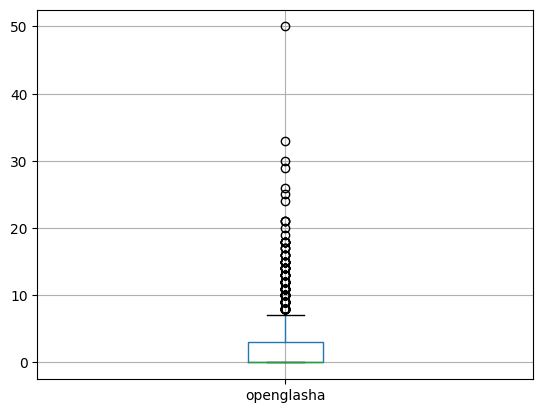

In [21]:
data.loc[:,['openglasha']].boxplot()
plt.show()

**exit**

In [22]:
data['exit'].unique()

array([0, nan, 1, 'поиск', 'почта'], dtype=object)

In [23]:
data = data.dropna(subset=['exit']).reset_index(drop=True)

In [24]:
data['exit'].unique()

array([0, 1, 'поиск', 'почта'], dtype=object)

**firstclick**

In [25]:
data['firstclick'].unique()

array(['поиск', 0, 'почта', 'соцсеть', 'undefined', nan], dtype=object)

In [26]:
data.loc[data['firstclick']=='undefined'] = 0

In [27]:
data['firstclick'] = data['firstclick'].fillna(value=0)

In [28]:
data['firstclick'].unique()

array(['поиск', 0, 'почта', 'соцсеть'], dtype=object)

**loginchoose**

In [29]:
data['loginchoose'].unique()

array(['Pom_Rezh125%', 0, 'pomrezh', '123abc', 'undefined', nan],
      dtype=object)

In [30]:
data = data.dropna(subset=['loginchoose']).reset_index(drop=True)

In [31]:
data['loginchoose'].unique()

array(['Pom_Rezh125%', 0, 'pomrezh', '123abc', 'undefined'], dtype=object)

**commtypes**

In [32]:
data['commtypes'].unique()

array(['Сообщество по интересам', 0, 'Мероприятие', 'Публичная страница',
       'Тематическое сообщество', 'Бренд или организация', 'Бизнес', nan],
      dtype=object)

In [33]:
data = data.dropna(subset=['commtypes']).reset_index(drop=True)

In [34]:
data['commtypes'].unique()

array(['Сообщество по интересам', 0, 'Мероприятие', 'Публичная страница',
       'Тематическое сообщество', 'Бренд или организация', 'Бизнес'],
      dtype=object)

**commdescription**

In [35]:
data['commdescription'].unique()

array(['Уважаемые участники спектакля! Данное сообщество предназначено для обмена важной информацией о спектакле. Кроме того, Вы можете общаться друг с другом на темы, связанные со спектаклем. Убедительно просим Вас формулировать свои мысли четко и писать в данном сообществе только о деталях постановки. Просим Вас написать администратору сообщества, какие участники спектакля еще не присутствуют здесь.',
       0,
       'Всем привет! Это сообщество создано для участников спектакля. Здесь будет собрана важная информация, и можно просто пообщаться друг с другом. Но комментарии совсем не по делу будут удаляться. Если вы увидите, что каких-то участников тут не хватает, напишите мне.',
       '🎭Сообщество для участников спектакля «Сон в летнюю ночь». Только важное.',
       nan], dtype=object)

In [36]:
data = data.dropna(subset=['commdescription']).reset_index(drop=True)

In [37]:
data['commdescription'].unique()

array(['Уважаемые участники спектакля! Данное сообщество предназначено для обмена важной информацией о спектакле. Кроме того, Вы можете общаться друг с другом на темы, связанные со спектаклем. Убедительно просим Вас формулировать свои мысли четко и писать в данном сообществе только о деталях постановки. Просим Вас написать администратору сообщества, какие участники спектакля еще не присутствуют здесь.',
       0,
       'Всем привет! Это сообщество создано для участников спектакля. Здесь будет собрана важная информация, и можно просто пообщаться друг с другом. Но комментарии совсем не по делу будут удаляться. Если вы увидите, что каких-то участников тут не хватает, напишите мне.',
       '🎭Сообщество для участников спектакля «Сон в летнюю ночь». Только важное.'],
      dtype=object)

**savepicture**

In [38]:
data['savepicture'].unique()

array([4, 0, '1,5,3,2,4', 2.1, 2, '1,3,2', 3.5, 5.2, '2,5,3', '2,4,5',
       '1,5,2,3,4', 2.5, 7, '4,5,2', 2.4, 4.2, 3, 5, 1, '4,2,5', 5.4,
       '3,2,4,5', 6, '5,2,4', '5,2,2', '2,5,8', '5,4,2', 8, '2,5,4', 6.8,
       1.2, '2,4,8,7', '1,2,4', 2.3, 2.8, 2.2, 6.2, '8,3,4', '1,2,3,4,5',
       '2,1,5,8,7', 4.5, '2,7,8', '2,5,6,8,4', 5.5, '1,2,4,5', 3.8, 1.6,
       '1,2,6,5', '1,2,3,5', '2,3,4,5', '7,1,4,2', '2,6,4,8,7,5', '2,8,6',
       '1,5,2', '2,4,6,7,8', 7.5, 8.4, 1.3, '3,1,2', '3,2,1',
       '4,8,7,2,5,6', 7.3, 8.7, '5,2,1,4', 3.3, '1,2,2', '5,2,3,1,4,8',
       '1,2,3', 1.4, '1,2,5', '1,5,5,8,8,8,8,8,7,6,5,2,7,1,1,3,3', 1.1,
       '7,8,2,4,3', 8.5, 6.4, '3,4,7,8', '2,1,4', 3.7, '3,5,8', 6.7,
       '3,1,7', '2,8,7', '1,7,8,3', 8.2, '4,3,2,1,5', '1,2,4,6,7,8',
       '2,1,4,7,8', '4,4,2,2', 3.2, '3,6,5,4', '8,5,1', '1,5,3', 5.6,
       '1,2,8,6', 3.1, '1,3,6', '8,7,5', '5,2,3,8', '2,1,3,5,4', '5,2,5',
       '2,2,4,5', 1.5, nan, '3,5,4', '6,3,7', 4.3, '2,1,7', 5.7, 1.7, 2.7,


In [39]:
data = data.dropna(subset=['savepicture']).reset_index(drop=True)

In [40]:
data['savepicture'].unique()

array([4, 0, '1,5,3,2,4', 2.1, 2, '1,3,2', 3.5, 5.2, '2,5,3', '2,4,5',
       '1,5,2,3,4', 2.5, 7, '4,5,2', 2.4, 4.2, 3, 5, 1, '4,2,5', 5.4,
       '3,2,4,5', 6, '5,2,4', '5,2,2', '2,5,8', '5,4,2', 8, '2,5,4', 6.8,
       1.2, '2,4,8,7', '1,2,4', 2.3, 2.8, 2.2, 6.2, '8,3,4', '1,2,3,4,5',
       '2,1,5,8,7', 4.5, '2,7,8', '2,5,6,8,4', 5.5, '1,2,4,5', 3.8, 1.6,
       '1,2,6,5', '1,2,3,5', '2,3,4,5', '7,1,4,2', '2,6,4,8,7,5', '2,8,6',
       '1,5,2', '2,4,6,7,8', 7.5, 8.4, 1.3, '3,1,2', '3,2,1',
       '4,8,7,2,5,6', 7.3, 8.7, '5,2,1,4', 3.3, '1,2,2', '5,2,3,1,4,8',
       '1,2,3', 1.4, '1,2,5', '1,5,5,8,8,8,8,8,7,6,5,2,7,1,1,3,3', 1.1,
       '7,8,2,4,3', 8.5, 6.4, '3,4,7,8', '2,1,4', 3.7, '3,5,8', 6.7,
       '3,1,7', '2,8,7', '1,7,8,3', 8.2, '4,3,2,1,5', '1,2,4,6,7,8',
       '2,1,4,7,8', '4,4,2,2', 3.2, '3,6,5,4', '8,5,1', '1,5,3', 5.6,
       '1,2,8,6', 3.1, '1,3,6', '8,7,5', '5,2,3,8', '2,1,3,5,4', '5,2,5',
       '2,2,4,5', 1.5, '3,5,4', '6,3,7', 4.3, '2,1,7', 5.7, 1.7, 2.7, 7.2,


**authorN**

In [41]:
data['authorN'].unique()

array([nan, 0, 1, 2, 3, 6], dtype=object)

In [42]:
data['authorN'] = data['authorN'].fillna(value=0)

C:\Users\ildar\AppData\Local\Temp\ipykernel_13164\1235246818.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['authorN'] = data['authorN'].fillna(value=0)


In [43]:
data['authorN'].unique()

array([0, 1, 2, 3, 6], dtype=int64)

**authortime**

In [44]:
data['authortime'].unique()

array([nan, 0, 9, 5, 10, 22, 16, 12, 15, 6, 56, 19, 2, 18, 27, 13, 3, 14,
       1, 33, 20, 39, 34, 11, 7, 35, 26, 8, 4, 17, 59, 23, 31, 25, 28, 42,
       21, 36, 138, 30, 29, 24, 41, 46, 37, 38, 49, 48, 57], dtype=object)

In [45]:
data['authortime'] = data['authortime'].fillna(value=0)

C:\Users\ildar\AppData\Local\Temp\ipykernel_13164\907513359.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['authortime'] = data['authortime'].fillna(value=0)


In [46]:
data['authortime'].unique()

array([  0,   9,   5,  10,  22,  16,  12,  15,   6,  56,  19,   2,  18,
        27,  13,   3,  14,   1,  33,  20,  39,  34,  11,   7,  35,  26,
         8,   4,  17,  59,  23,  31,  25,  28,  42,  21,  36, 138,  30,
        29,  24,  41,  46,  37,  38,  49,  48,  57], dtype=int64)

**picturechoose**

In [47]:
data['picturechoose'].unique()

array([4, 0, 2.4, 2, 1.3, 3.5, 2.3, '2,4,5', 2.5, 7, 3, 5, 1, 4.5, 6, 8,
       2.8, 1.2, '2,3,4,5', '2,4,8', '2,4,5,6,7,8', '2,6,8', 5.7, nan,
       '1,2,3', 5.8, 4.6, '3,4,7,8', '2,7,8', 1.8, '1,3,5', 6.8,
       '2,3,5,8', '1,2,3,4,5', 1.5, '3,4,5', '1,2,5', '1,2,7', '1,2,4',
       3.4, '2,5,6,7', '2,4,5,8', '2,4,5,6,8', '4,7,8', '2,4,6', 1.6, 4.8,
       '2,4,5,7,8', '2,3,5', 2.6, 7.8, 6.7, '1,2,4,5', '2,5,7,8', '1,2,6',
       1.4, 3.6, '1,2,3,4,5,6,7,8', '2,4,5,7', '2,3,4', 4.7, '2,4,6,8',
       '2,4,6,7,8', '2,5,6,8', '1,4,6,8', 3.8, '4,6,7,8', '2,4,5,6',
       '6,7,8', '1,3,4,5', '2,5,8', '4,5,8', '1,4,5', 2.7, '5,6,7,8',
       '4,6,8', '1,3,5,7,8', '1,2,3,4', '1,5,8', '2,5,7', '1,2,3,5', 5.6,
       '1,3,6,7,8', datetime.datetime(2024, 5, 1, 0, 0),
       datetime.datetime(2024, 2, 1, 0, 0),
       datetime.datetime(2024, 5, 2, 0, 0),
       datetime.datetime(2024, 8, 2, 0, 0),
       datetime.datetime(2024, 7, 5, 0, 0),
       datetime.datetime(2024, 4, 2, 0, 0), '2,4,7'

In [48]:
data = data.dropna(subset=['picturechoose']).reset_index(drop=True)

In [49]:
data['picturechoose'].unique()

array([4, 0, 2.4, 2, 1.3, 3.5, 2.3, '2,4,5', 2.5, 7, 3, 5, 1, 4.5, 6, 8,
       2.8, 1.2, '2,3,4,5', '2,4,8', '2,4,5,6,7,8', '2,6,8', 5.7, '1,2,3',
       5.8, 4.6, '3,4,7,8', '2,7,8', 1.8, '1,3,5', 6.8, '2,3,5,8',
       '1,2,3,4,5', 1.5, '3,4,5', '1,2,5', '1,2,7', '1,2,4', 3.4,
       '2,5,6,7', '2,4,5,8', '2,4,5,6,8', '4,7,8', '2,4,6', 1.6, 4.8,
       '2,4,5,7,8', '2,3,5', 2.6, 7.8, 6.7, '1,2,4,5', '2,5,7,8', '1,2,6',
       1.4, 3.6, '1,2,3,4,5,6,7,8', '2,4,5,7', '2,3,4', 4.7, '2,4,6,8',
       '2,4,6,7,8', '2,5,6,8', '1,4,6,8', 3.8, '4,6,7,8', '2,4,5,6',
       '6,7,8', '1,3,4,5', '2,5,8', '4,5,8', '1,4,5', 2.7, '5,6,7,8',
       '4,6,8', '1,3,5,7,8', '1,2,3,4', '1,5,8', '2,5,7', '1,2,3,5', 5.6,
       '1,3,6,7,8', datetime.datetime(2024, 5, 1, 0, 0),
       datetime.datetime(2024, 2, 1, 0, 0),
       datetime.datetime(2024, 5, 2, 0, 0),
       datetime.datetime(2024, 8, 2, 0, 0),
       datetime.datetime(2024, 7, 5, 0, 0),
       datetime.datetime(2024, 4, 2, 0, 0), '2,4,7',
   

**picturechoosedelete**

In [50]:
data['picturechoosedelete'].unique()

array([nan, 0, 5.1, 1, '2,2,2,2,2', 5.5, 3, '2,4,4', 4, 2, 5,
       '4,2,5,4,4,5', 7, 8, 1.2, 6.6, '2,4,5', '6,2,5,2,6,6', 5.2, 4.2,
       '7,7,5', 6, '4,3,2,1,5', '1,2,5', 3.3, 2.1, '5,4,2', 5.4, 5.6, 8.8,
       5.7, 4.4, 2.5, 2.4, '4,2,7,7,2', 2.2, '5,2,4', '4,3,5,1,2',
       '2,4,8', '1,2,5,4', 6.7, '3,6,3', '2,4,6,8', '5,8,5,2,6', 1.3,
       '4,8,5,2,4', 7.5, 4.8, '4,5,4,5', 3.1, 1.1, '7,1,2', '5,8,5', 5.3,
       '5,2,2', '2,8,6,5', '3,3,3,3', 7.2, 6.2,
       datetime.datetime(2024, 2, 3, 0, 0),
       datetime.datetime(2024, 2, 1, 0, 0), '1,3,2', '5,4,5,2',
       datetime.datetime(2024, 4, 2, 0, 0), '2,2,4',
       datetime.datetime(2024, 5, 2, 0, 0), '2.2000000000000002',
       datetime.datetime(2024, 4, 5, 0, 0), '3,1,5', '8,7,8',
       datetime.datetime(2024, 4, 3, 0, 0), '2,2,1',
       datetime.datetime(2024, 1, 2, 0, 0), '6,8,7,5,8', '5,5,4,1',
       '2,5,2,5,4', '5,1,4,2,1,4,5', '2,8,5',
       datetime.datetime(2024, 4, 7, 0, 0),
       datetime.datetime(2024, 5

In [51]:
data['picturechoosedelete'] = data['picturechoosedelete'].fillna(value=0)

In [52]:
data['picturechoosedelete'].unique()

array([0, 5.1, 1, '2,2,2,2,2', 5.5, 3, '2,4,4', 4, 2, 5, '4,2,5,4,4,5', 7,
       8, 1.2, 6.6, '2,4,5', '6,2,5,2,6,6', 5.2, 4.2, '7,7,5', 6,
       '4,3,2,1,5', '1,2,5', 3.3, 2.1, '5,4,2', 5.4, 5.6, 8.8, 5.7, 4.4,
       2.5, 2.4, '4,2,7,7,2', 2.2, '5,2,4', '4,3,5,1,2', '2,4,8',
       '1,2,5,4', 6.7, '3,6,3', '2,4,6,8', '5,8,5,2,6', 1.3, '4,8,5,2,4',
       7.5, 4.8, '4,5,4,5', 3.1, 1.1, '7,1,2', '5,8,5', 5.3, '5,2,2',
       '2,8,6,5', '3,3,3,3', 7.2, 6.2,
       datetime.datetime(2024, 2, 3, 0, 0),
       datetime.datetime(2024, 2, 1, 0, 0), '1,3,2', '5,4,5,2',
       datetime.datetime(2024, 4, 2, 0, 0), '2,2,4',
       datetime.datetime(2024, 5, 2, 0, 0), '2.2000000000000002',
       datetime.datetime(2024, 4, 5, 0, 0), '3,1,5', '8,7,8',
       datetime.datetime(2024, 4, 3, 0, 0), '2,2,1',
       datetime.datetime(2024, 1, 2, 0, 0), '6,8,7,5,8', '5,5,4,1',
       '2,5,2,5,4', '5,1,4,2,1,4,5', '2,8,5',
       datetime.datetime(2024, 4, 7, 0, 0),
       datetime.datetime(2024, 5, 3, 

**citation, citationcode**

In [53]:
data['citation'].unique()

array([nan, 0, 'd_teatro.diary.org',
       'zimin.photography.org fomin.blogspot.org',
       'zimin.photography.org ermitazh.theatre.ru',
       'd_teatro.diary.org globustheatre.org ermitazh.theatre.ru',
       'globustheatre.org',
       'ermitazh.theatre.ru d_teatro.diary.org globustheatre.org',
       'shutterstock.com', 'globustheatre.org d_teatro.diary.org',
       'fomin.blogspot.org', 'ermitazh.theatre.ru',
       'd_teatro.diary.org globustheatre.org',
       'ermitazh.theatre.ru globustheatre.org',
       'globustheatre.org ermitazh.theatre.ru', 'liveinternet.ru',
       'd_teatro.diary.org ermitazh.theatre.ru',
       'd_teatro.diary.org zimin.photography.org', 'stockfoto.com',
       'd_teatro.diary.org stockfoto.com',
       'ermitazh.theatre.ru d_teatro.diary.org',
       'd_teatro.diary.org fomin.blogspot.org',
       'shutterstock.com ermitazh.theatre.ru', 'zimin.photography.org',
       'fomin.blogspot.org d_teatro.diary.org zimin.photography.org',
       'fomin.blog

In [54]:
data['citation'] = data['citation'].fillna(value=0)

In [55]:
data['citation'].unique()

array([0, 'd_teatro.diary.org',
       'zimin.photography.org fomin.blogspot.org',
       'zimin.photography.org ermitazh.theatre.ru',
       'd_teatro.diary.org globustheatre.org ermitazh.theatre.ru',
       'globustheatre.org',
       'ermitazh.theatre.ru d_teatro.diary.org globustheatre.org',
       'shutterstock.com', 'globustheatre.org d_teatro.diary.org',
       'fomin.blogspot.org', 'ermitazh.theatre.ru',
       'd_teatro.diary.org globustheatre.org',
       'ermitazh.theatre.ru globustheatre.org',
       'globustheatre.org ermitazh.theatre.ru', 'liveinternet.ru',
       'd_teatro.diary.org ermitazh.theatre.ru',
       'd_teatro.diary.org zimin.photography.org', 'stockfoto.com',
       'd_teatro.diary.org stockfoto.com',
       'ermitazh.theatre.ru d_teatro.diary.org',
       'd_teatro.diary.org fomin.blogspot.org',
       'shutterstock.com ermitazh.theatre.ru', 'zimin.photography.org',
       'fomin.blogspot.org d_teatro.diary.org zimin.photography.org',
       'fomin.blogspot.

In [56]:
data['citationcode'].unique()

array([nan, 0, 2, 3.1, 3.5, '2,4,5', 4, '5,2,4', 7, 4.2, 1, 5, 2.4, 5.4,
       4.5, 6, 2.5, '2,4,4,5', 4.4, 2.3, 8, 2.8, 5.2, 2.1, 7.5, 8.4, 3,
       '1,2,3', 1.8, '5,2,3,8', '1,2,1,3,5,4', '3,5,4', '1,2,5', 5.3,
       '2,4,5,8', '6,8,4,5,2', '2,4,8', 6.8, '5,4,2', 5.8, 2.6,
       '1,1,2,3,4,5', 7.6, 8.2, '2,5,1', '1,7,6', '4,2,8', 8.5, '2,4,5,4',
       '2,4,6,8', '4,2,5', 1.3, 5.7, 2.7, 7.8, '2,2,8,5,2,6,8,5', 3.2,
       '1,2,4,5,8', '4,5,8', 1.2, 5.1, 1.4, '1,2,4', '8,7,6,5', '8,7,2',
       '2,5,4', '4,2,6,5', '2,1,5', 2.2, 5.6, 7.7, 8.1, '5,2,8,7,4', 1.5,
       '2,3,1,4,5', 6.4, datetime.datetime(2024, 5, 1, 0, 0),
       datetime.datetime(2024, 2, 1, 0, 0),
       datetime.datetime(2024, 2, 3, 0, 0),
       datetime.datetime(2024, 8, 2, 0, 0), '2,5,5,4',
       datetime.datetime(2024, 4, 2, 0, 0), '2,8,4,2',
       '2.2000000000000002', '4,2,4', datetime.datetime(2024, 2, 5, 0, 0),
       datetime.datetime(2024, 5, 7, 0, 0),
       datetime.datetime(2024, 7, 2, 0, 0),
     

In [57]:
data['citationcode'] = data['citationcode'].fillna(value=0)

In [58]:
data['citationcode'].unique()

array([0, 2, 3.1, 3.5, '2,4,5', 4, '5,2,4', 7, 4.2, 1, 5, 2.4, 5.4, 4.5,
       6, 2.5, '2,4,4,5', 4.4, 2.3, 8, 2.8, 5.2, 2.1, 7.5, 8.4, 3,
       '1,2,3', 1.8, '5,2,3,8', '1,2,1,3,5,4', '3,5,4', '1,2,5', 5.3,
       '2,4,5,8', '6,8,4,5,2', '2,4,8', 6.8, '5,4,2', 5.8, 2.6,
       '1,1,2,3,4,5', 7.6, 8.2, '2,5,1', '1,7,6', '4,2,8', 8.5, '2,4,5,4',
       '2,4,6,8', '4,2,5', 1.3, 5.7, 2.7, 7.8, '2,2,8,5,2,6,8,5', 3.2,
       '1,2,4,5,8', '4,5,8', 1.2, 5.1, 1.4, '1,2,4', '8,7,6,5', '8,7,2',
       '2,5,4', '4,2,6,5', '2,1,5', 2.2, 5.6, 7.7, 8.1, '5,2,8,7,4', 1.5,
       '2,3,1,4,5', 6.4, datetime.datetime(2024, 5, 1, 0, 0),
       datetime.datetime(2024, 2, 1, 0, 0),
       datetime.datetime(2024, 2, 3, 0, 0),
       datetime.datetime(2024, 8, 2, 0, 0), '2,5,5,4',
       datetime.datetime(2024, 4, 2, 0, 0), '2,8,4,2',
       '2.2000000000000002', '4,2,4', datetime.datetime(2024, 2, 5, 0, 0),
       datetime.datetime(2024, 5, 7, 0, 0),
       datetime.datetime(2024, 7, 2, 0, 0),
       dat

**mail1, mail2, wall1, private1, private2, wall2, wall2comment3, wall2comment4, wall2comment5, private3, private4, private5, private6, wall3, wall4, copymail**

In [59]:
data = data.dropna(subset=['mail1']).reset_index(drop=True)
data = data.dropna(subset=['mail2']).reset_index(drop=True)
data = data.dropna(subset=['wall1']).reset_index(drop=True)
data = data.dropna(subset=['private1']).reset_index(drop=True)
data = data.dropna(subset=['private2']).reset_index(drop=True)
data = data.dropna(subset=['wall2']).reset_index(drop=True)
data = data.dropna(subset=['wall2comment3']).reset_index(drop=True)
data = data.dropna(subset=['wall2comment4']).reset_index(drop=True)
data = data.dropna(subset=['wall2comment5']).reset_index(drop=True)
data = data.dropna(subset=['private3']).reset_index(drop=True)
data = data.dropna(subset=['private4']).reset_index(drop=True)
data = data.dropna(subset=['private5']).reset_index(drop=True)
data = data.dropna(subset=['private6']).reset_index(drop=True)
data = data.dropna(subset=['wall3']).reset_index(drop=True)
data = data.dropna(subset=['wall4']).reset_index(drop=True)
data = data.dropna(subset=['copymail']).reset_index(drop=True)

In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2241 entries, 0 to 2240
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   GGlevel              2241 non-null   int64 
 1   fulltime             2241 non-null   object
 2   openglasha           2241 non-null   int32 
 3   exit                 2241 non-null   object
 4   firstclick           2241 non-null   object
 5   loginchoose          2241 non-null   object
 6   help                 2241 non-null   object
 7   commtypes            2241 non-null   object
 8   commname             2241 non-null   object
 9   commеtheme           2241 non-null   object
 10  commdescription      2241 non-null   object
 11  commfoto             2241 non-null   object
 12  privacy              2241 non-null   object
 13  notion               2241 non-null   object
 14  savepicture          2241 non-null   object
 15  authorN              2241 non-null   int64 
 16  author

#### Работа с типом данных

In [61]:
data['fulltime'].unique()

array([767, 0, 871, 631, 866, 755, 568, 803, 1143, 686, 914, 697, 1188,
       661, 678, 775, 937, 1049, 891, 694, 647, 1071, 885, 721, 705, 829,
       746, 771, 763, 1056, 627, 660, 593, 615, 713, 596, 1035, 1145, 693,
       899, 732, 807, 788, 582, 962, 711, 834, 1237, 635, 738, 964, 704,
       826, 618, 1501, 876, 581, 761, 930, 542, 815, 839, 810, 808, 653,
       1012, 633, 494, 809, 780, 984, 1151, 741, 707, 992, 855, 779, 850,
       1093, 597, 884, 532, 548, 605, 623, 498, 748, 709, 696, 781, 598,
       656, 706, 539, 672, 1037, 497, 584, 717, 638, 645, 630, 1187, 843,
       818, 792, 560, 708, 1125, 817, 567, 549, 725, 666, 1116, 538, 840,
       853, 945, 965, 1124, 936, 1079, 463, 1572, 669, 783, 798, 790, 526,
       1042, 849, 595, 499, 941, 634, 403, 640, 816, 856, 446, 325, 928,
       1013, 959, 765, 974, 845, 465, 580, 685, 1018, 1119, 1065, 903,
       574, 1039, 1103, 995, 1324, 999, 1241, 1019, 1267, 1681, 1415,
       1043, 1006, 621, 893, 489, 665, 734, 699, 

In [62]:
data['fulltime'] = data['fulltime'].astype(float).fillna(value=data['fulltime'].median())

In [63]:
# Заменим на int и переведем в минуты
data['fulltime'] = data['fulltime'].astype(int) / 60

In [64]:
data['fulltime'] = data['fulltime'].astype(int)

In [65]:
data['fulltime'].unique()

array([12,  0, 14, 10,  9, 13, 19, 11, 15, 17, 16, 20, 25,  8, 18,  7, 26,
        6,  5, 22, 21, 28, 23, 30, 24, 27])

In [66]:
data['fulltime'] = data['fulltime'].astype(int)

In [67]:
data['fulltime'].describe()

count    2241.000000
mean        7.593485
std         7.078724
min         0.000000
25%         0.000000
50%         9.000000
75%        13.000000
max        30.000000
Name: fulltime, dtype: float64

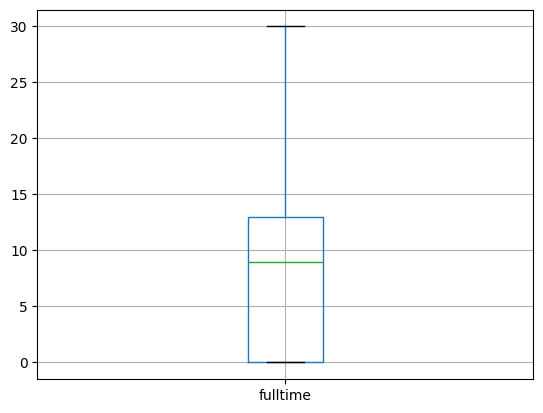

In [68]:
data.loc[:,['fulltime']].boxplot()
plt.show()

In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2241 entries, 0 to 2240
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   GGlevel              2241 non-null   int64 
 1   fulltime             2241 non-null   int32 
 2   openglasha           2241 non-null   int32 
 3   exit                 2241 non-null   object
 4   firstclick           2241 non-null   object
 5   loginchoose          2241 non-null   object
 6   help                 2241 non-null   object
 7   commtypes            2241 non-null   object
 8   commname             2241 non-null   object
 9   commеtheme           2241 non-null   object
 10  commdescription      2241 non-null   object
 11  commfoto             2241 non-null   object
 12  privacy              2241 non-null   object
 13  notion               2241 non-null   object
 14  savepicture          2241 non-null   object
 15  authorN              2241 non-null   int64 
 16  author

In [70]:
data.head(3)

,GGlevel,fulltime,openglasha,exit,firstclick,loginchoose,help,commtypes,commname,commеtheme,commdescription,commfoto,privacy,notion,savepicture,authorN,authortime,savepictureN,picturechoose,picturechooseN,picturechoosedelete,citation,citationcode,mail1,mail2,wall1,private1,private2,wall2,wall2comment3,wall2comment4,wall2comment5,private3,private4,private5,private6,wall3,wall4,copymail
0,2,12,0,0,поиск,Pom_Rezh125%,0,Сообщество по интересам,Спектакль «Сон в летнюю ночь»,Постановка спектакля,Уважаемые участники спектакля! Данное сообщест...,Изображение 2,Закрытое,0,4,0,0,1,4,1,0,0,0,2,1,"Привет! Я думаю, что повезло всем, кто участву...","Не думаю, что стоит об этом кому-то рассказывать.","Не думаю, что стоит заходить на такой сайт","Да ладно тебе, ты думаешь так, другие ребята м...",2,3,1,3,3,1,6,Скачай отсюда: www.videoavi.com,"Ребята, напишите здесь свои комментарии, что у...",soloveym@teatr.ru
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [71]:
#Осталось данных в %
print(2241/2796*100)

80.15021459227468


In [73]:
categorical_features = ['exit','firstclick','loginchoose','help','commtypes','commname','commеtheme','commdescription','commfoto','privacy','notion','savepicture','savepictureN','picturechoose','picturechooseN','picturechoosedelete','citation','citationcode','mail1','mail2','wall1','private1','private2','wall2','wall2comment3','wall2comment4','wall2comment5','private3','private4','private5','private6','wall3','wall4','copymail']

In [74]:
for e in categorical_features:
    data[e]=data[e].astype(str)

In [75]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder()
df = pd.DataFrame(data)
cat_columns = df.select_dtypes('object').columns

df_oe = oe.fit_transform(df[cat_columns])
df_oe

array([[  0.,   1.,   2., ...,   3.,   3.,  32.],
       [  0.,   0.,   0., ...,   0.,   0.,  16.],
       [  0.,   0.,   0., ...,   0.,   0.,  16.],
       ...,
       [  2.,   0.,   1., ...,   1.,   2., 127.],
       [  2.,   0.,   1., ...,   1.,   4., 215.],
       [  2.,   0.,   2., ...,   3.,   4., 151.]])

In [76]:
df[cat_columns] = df_oe
df

,GGlevel,fulltime,openglasha,exit,firstclick,loginchoose,help,commtypes,commname,commеtheme,commdescription,commfoto,privacy,notion,savepicture,authorN,authortime,savepictureN,picturechoose,picturechooseN,picturechoosedelete,citation,citationcode,mail1,mail2,wall1,private1,private2,wall2,wall2comment3,wall2comment4,wall2comment5,private3,private4,private5,private6,wall3,wall4,copymail
0,2,12,0,0.0,1.0,2.0,0.0,5.0,3.0,2.0,2.0,2.0,1.0,0.0,253.0,0,0,1.0,81.0,1.0,0.0,0.0,0.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,3.0,1.0,3.0,3.0,1.0,5.0,3.0,3.0,32.0
1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0
2,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0
3,3,14,1,0.0,1.0,2.0,0.0,3.0,2.0,2.0,1.0,1.0,1.0,1.0,60.0,0,0,6.0,50.0,5.0,66.0,0.0,0.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,3.0,1.0,2.0,3.0,2.0,3.0,3.0,2.0,121.0
4,3,10,6,0.0,2.0,2.0,0.0,3.0,3.0,2.0,2.0,3.0,1.0,1.0,152.0,0,0,3.0,25.0,1.0,1.0,1.0,13.0,2.0,1.0,2.0,1.0,2.0,1.0,5.0,4.0,1.0,3.0,3.0,3.0,5.0,3.0,2.0,121.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2236,0,0,0,2.0,0.0,2.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,1.0,223.0,0,0,5.0,76.0,6.0,38.0,0.0,0.0,1.0,2.0,2.0,1.0,2.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,3.0,17.0
2237,3,0,0,3.0,0.0,1.0,0.0,3.0,3.0,2.0,1.0,3.0,1.0,0.0,179.0,2,22,3.0,62.0,5.0,39.0,26.0,48.0,2.0,2.0,2.0,2.0,2.0,1.0,3.0,5.0,1.0,1.0,1.0,1.0,3.0,3.0,3.0,172.0
2238,1,0,0,2.0,0.0,1.0,0.0,5.0,3.0,2.0,2.0,4.0,1.0,0.0,177.0,0,0,3.0,57.0,5.0,0.0,1.0,13.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,2.0,1.0,1.0,1.0,3.0,5.0,1.0,2.0,127.0
2239,0,0,0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,0,0,1.0,1.0,1.0,0.0,33.0,1.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,1.0,4.0,215.0


In [78]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.model_selection import train_test_split

In [83]:
features = df.drop(['GGlevel'], axis=1)
target = df['GGlevel']

x, x_test, y, y_test = train_test_split(features, target, test_size=0.2, train_size=0.8)
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size = 0.25, train_size = 0.75)

In [89]:
feature_names = features.columns.tolist()

**Расшифровка**
- x_train, y_train - обучающая выборка
- x_valid, y_valid - валидационная выборка
- x_test, y_test - тестовая выборка

In [92]:
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [85]:
model = LinearRegression()
model.fit(x_train, y_train)

preds = model.predict(x_test)
model.intercept_, model.coef_

(-0.009285049569883741,
 array([-0.00601362, -0.0092239 , -0.05323429,  0.04925845,  0.09510133,
         0.02850885, -0.03530706,  0.15674347,  0.02106831,  0.0016521 ,
         0.03064531, -0.31397571, -0.14978155, -0.00059319, -0.00240463,
         0.0089586 ,  0.00245541, -0.00119622,  0.04692802,  0.00044289,
        -0.00690104,  0.00801473,  0.0163662 , -0.10510378, -0.06671718,
        -0.2107079 ,  0.16579879, -0.02145061,  0.06220057,  0.14827019,
        -0.0412881 ,  0.05245538,  0.03105122,  0.09376915,  0.11911194,
         0.04659319,  0.0566799 ,  0.00140286]))

In [87]:
def show_coef(names, coef, positive=False):
    tmp_df = pd.Series(index=names, data=coef).sort_values(ascending=False)
    if positive:
        sns.barplot(x=abs(tmp_df.values), y=tmp_df.index)
    else:
        sns.barplot(x=tmp_df.values, y=tmp_df.index)
    plt.tight_layout
    plt.show()

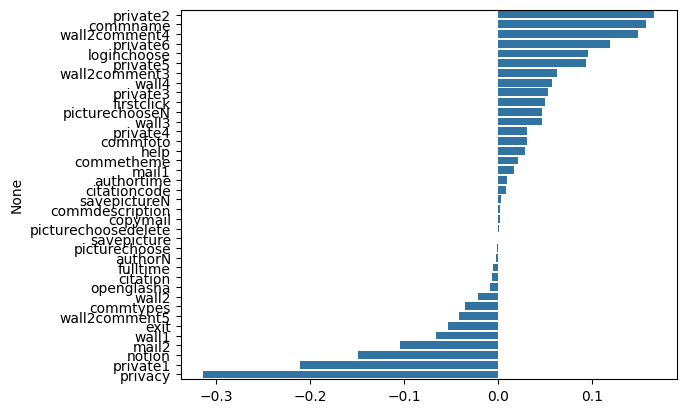

In [93]:
show_coef(feature_names, model.coef_)